# M6.3 — Generated sequence validation

Plan: [`plans/milestone_06/06_sequence_generation_plan.md`](../../plans/milestone_06/06_sequence_generation_plan.md).  
Next: `06_4_generate_sequences.ipynb`.

Validates an existing M6.2 sequence without regenerating physics or using persistent source caches. Checks manifest completeness, portable provenance, frame ordering, role alignment, image dimensions, anomaly metadata, cache policy, and the explicitly approximate decoded-JPEG composition check.

Expected input: historical Phase 2 artifact with `use_persistent_cache=False` from `06_2_generate_sequences_no_cache.ipynb`. Persistent cache miss/hit demonstration belongs in `06_4_generate_sequences.ipynb`.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[fem,dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from IPython.display import display

import gummybear_validation.milestone_06.validation as m6_validation
from gummybear_validation.milestone_06 import (
    load_sequence_manifest,
    manifest_audit_summary,
    preview_sequence_roles,
    validate_generated_sequence,
)
from gummybear_validation.notebook_tools import run_installed_pytest_tests

SEQUENCE_DIR = ROOT / "data" / "generated" / "m6_2" / "bear_m6_smoke_001"


## 1. Validate the generated smoke sequence

The structured result distinguishes hard contract errors from informational warnings. Exact pre-JPEG composition is not claimed because M6.2 does not persist numeric pre-compression arrays.

This notebook also asserts the historical cache policy: the validated sequence must record that persistent source caches were not used.


In [3]:
if not SEQUENCE_DIR.is_dir():
    raise FileNotFoundError(
        f"Expected historical M6.2 sequence at {display_path(SEQUENCE_DIR)}. "
        "Reproduce it from notebooks/milestone_06/06_2_generate_sequences_no_cache.ipynb "
        "with use_persistent_cache=False before running this validation notebook."
    )

manifest = load_sequence_manifest(SEQUENCE_DIR)
caches = manifest.get("caches", {})
if caches.get("persistent_cache_used") is not False:
    raise AssertionError(
        "M6.3 validates historical Phase 2 artifacts only. "
        f"Expected caches.persistent_cache_used=False, got {caches.get('persistent_cache_used')!r}. "
        "Regenerate with 06_2_generate_sequences_no_cache.ipynb "
        "(use_persistent_cache=False), not the M6.4 cache demo."
    )

validation_result = validate_generated_sequence(SEQUENCE_DIR)
display(validation_result.summary())
if not validation_result.ok:
    raise AssertionError(
        "Generated sequence validation failed:\n- "
        + "\n- ".join(validation_result.errors)
    )
print("Historical M6.2 artifact confirmed: persistent source caches were not used.")


{'sequence_id': 'bear_m6_smoke_001',
 'sequence_dir': 'data/generated/m6_2/bear_m6_smoke_001',
 'ok': True,
 'errors': [],
 'warnings': ['Pre-JPEG anomaly/composition identity not checked: current M6.2 artifacts do not persist numeric pre-compression arrays.',
  'Observed/particle identity was checked approximately on decoded JPEG files; this is not an exact pre-JPEG residual check.'],
 'frame_count': 6,
 'role_names': ['clean', 'particle', 'observed', 'anomaly'],
 'checked_file_count': 43,
 'manifest_schema_version': '1.6-m6-draft',
 'composition_policy': 'pre_jpeg_numeric_arrays',
 'post_jpeg_identity_checked': True,
 'pre_jpeg_identity_checked': False}

Historical M6.2 artifact confirmed: persistent source caches were not used.


## 2. Run installed-package pytest checks

Focused tests validate the installed package without invoking FEM, source-ray generation, notebooks, or persistent source caches. The M6.4 cache-contract pytest lives in `06_4_generate_sequences.ipynb`.


In [4]:
run_installed_pytest_tests(
    m6_validation,
    (
        "test_generated_sequence_artifact_contract",
        "test_generated_sequence_rejects_absolute_workbook_path",
        "test_generated_sequence_labels_composition_check_domain",
    ),
)


Milestone 6.3
Test executed: test_generated_sequence_artifact_contract()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_06/validation.py . [100%]
============================== 1 passed in 0.95s ===============================

Test proves: A coherent historical M6.2 sequence (persistent_cache_used=False) passes manifest,
             filename, role-alignment, portability, provenance, and decoded-image validation.
Milestone 6.3
Test executed: test_generated_sequence_rejects_absolute_workbook_path()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_06/validation.py . [100%]
============================== 1 passed in 0.88s ===============================

Test proves: Machine-local workbook paths are rejected from portable M6 manifests.
Milestone 6.3
Test executed: test_generated_sequence_labels_composition_check_domain()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_06/validation.py . [100%]

## 3. Inspect provenance and aligned roles

Display the first frame and the manifest fields that make workbook source coordinates and the representation contract auditable.

Manifests with schema `1.4-m6-draft` expose `setups.particles` (ordered list + count). Older `1.3` artifacts keep only `setups.particle` (first / singleton). Role directories are unchanged either way.


{'workbook': {'sequence_excel_row': 2,
  'sequence_sheet': 'sequences',
  'sha256': '4e6ac865c398b1c7c60e91a80f90270c993e3356568f5e71f79532ba7a378fde',
  'workbook_path': 'configs/m6/m6_generation_plan.xlsx'},
 'caches': {'persistent_cache_used': False,
  'clean_optical_cache_id': '83b9d7a583728c38f41e3a12e1a6e68e8da19ce0e33a7c5b5d2a5fad27e6a521',
  'particle_source_cache_id': '2b71544f544171d6d73ac35abce5b8cac4de6482fa96e9afdafc4aaf762bcfd1',
  'diffusion_operator_cache': None},
 'setup_coordinates': {'optical': {'workbook_name': 'm6_generation_plan.xlsx',
   'workbook_sheet': 'optical_setups',
   'source_excel_row': 2},
  'particle': {'workbook_name': 'm6_generation_plan.xlsx',
   'workbook_sheet': 'particles',
   'source_excel_row': 2},
  'diffusion': {'workbook_name': 'm6_generation_plan.xlsx',
   'workbook_sheet': 'diffusion_setups',
   'source_excel_row': 2},
  'camera': {'workbook_name': 'm6_generation_plan.xlsx',
   'workbook_sheet': 'camera_schedules',
   'source_excel_row': 2

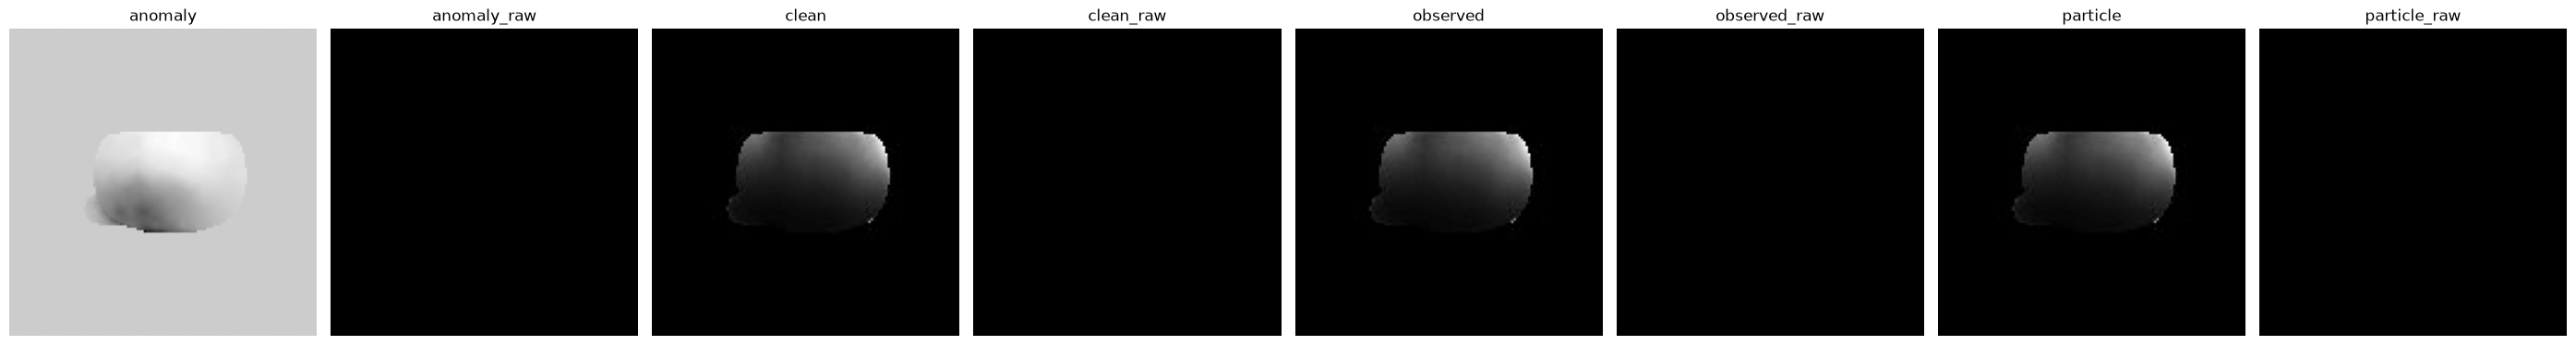

In [5]:
preview_sequence_roles(SEQUENCE_DIR)
manifest_audit_summary(manifest, validation_summary=validation_result.summary())
